In [ ]:
!pip install rawpy imageio numpy pandas matplotlib scikit-image scikit-learn huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.1 MB/s eta 0:00:00


In [ ]:
# Download dataset from HuggingFace
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="milan9999/dng_50",
    repo_type="dataset"
)

print("Dataset downloaded to:", dataset_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 57 files:   0%|          | 0/57 [00:00<?, ?it/s]

Dataset downloaded to: /root/.cache/huggingface/hub/datasets--milan9999--dng_50/snapshots/b61e7c6035c81f599f97a8bd2ebb9f3ac499fed1


In [ ]:
# libraries
import os
import rawpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, deltaE_ciede2000
import cv2

In [ ]:
# All .dng files inside the downloaded dataset folder
dng_files = [f for f in os.listdir(dataset_path) if f.endswith(".dng")]

print("Total images:", len(dng_files))

Total images: 56


In [ ]:
# main processing (raw → lab → chroma → metadata → deltaE)
results = []

for file in dng_files:

    path = os.path.join(dataset_path, file)

    with rawpy.imread(path) as raw:

        # raw to rgb
        rgb = raw.postprocess(
          use_camera_wb=True,
          no_auto_bright=True,
          output_bps=16
        )

        # resize image
        rgb = cv2.resize(rgb, (0,0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)

        # normalize
        rgb_norm = rgb / 65535.0

        # rgb to lab
        lab = rgb2lab(rgb_norm)

        # chroma
        a = lab[:, :, 1]
        b = lab[:, :, 2]
        chroma = np.sqrt(a**2 + b**2)
        mean_chroma = np.mean(chroma)

        # deltaE (baseline)
        rgb_ref = np.clip(rgb * 1.05, 0, 65535)
        lab_ref = rgb2lab(rgb_ref / 65535.0)
        deltaE = np.mean(deltaE_ciede2000(lab, lab_ref))

        # store data
        row = {
            "image_name": file,
            "mean_chroma": mean_chroma,
            "deltaE": deltaE,
            "black_level_r": raw.black_level_per_channel[0],
            "black_level_g1": raw.black_level_per_channel[1],
            "black_level_g2": raw.black_level_per_channel[2],
            "black_level_b": raw.black_level_per_channel[3],
            "white_level": raw.white_level,
            "wb_r": raw.camera_whitebalance[0],
            "wb_g1": raw.camera_whitebalance[1],
            "wb_g2": raw.camera_whitebalance[2],
            "wb_b": raw.camera_whitebalance[3]
        }

        results.append(row)

In [ ]:
# create dataframe
df = pd.DataFrame(results)

df.head()

,image_name,mean_chroma,deltaE,black_level_r,black_level_g1,black_level_g2,black_level_b,white_level,wb_r,wb_g1,wb_g2,wb_b
0,a0052-dgw_131.dng,4.774169,1.216854,0,0,0,0,15892,1.722656,1.0,1.523438,0.0
1,a0035-dgw_048.dng,17.056413,1.172656,0,0,0,0,15892,1.476562,1.0,1.632813,0.0
2,a0049-_I2E5952.dng,15.166775,1.406755,127,127,127,127,3700,1.945745,1.0,1.306829,0.0
3,a0015-DSC_0081.dng,10.300664,1.826687,0,0,0,0,4095,2.091551,1.0,1.577464,0.0
4,a0041-IMG_4972.dng,9.084906,0.515235,1024,1024,1024,1024,14400,2.019305,1.0,1.472008,0.0


In [ ]:
# saturation levels
df["saturation_level"] = pd.qcut(
    df["mean_chroma"],
    10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

In [ ]:
# save dataset
df.to_csv("final_milestone1_dataset.csv", index=False)

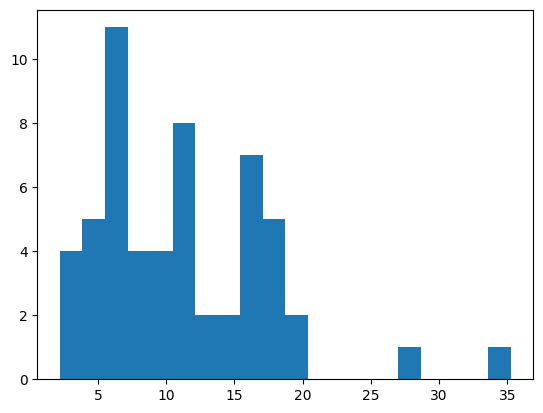

In [ ]:
# plot distribution
plt.hist(df["mean_chroma"], bins=20)
plt.show()

In [ ]:
# check deltaE
print(df["deltaE"].mean())

1.2439067452146335


In [ ]:
# prepare data for ML
X = df.drop(columns=["image_name", "saturation_level"])
y = df["saturation_level"]

In [ ]:
# train model
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# evaluate model
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)
accuracy=accuracy_score(y_test, pred)
print(accuracy)

0.75


In [ ]:
# train random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5


In [ ]:
# decision tree vs random forest
print("Decision Tree Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Decision Tree Accuracy: 0.75
Random Forest Accuracy: 0.5


In [ ]:
# check which features matter most
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False)

,0
mean_chroma,0.323881
wb_g2,0.146851
wb_r,0.137930
deltaE,0.130572
white_level,0.080635
black_level_g2,0.057698
black_level_g1,0.044047
black_level_r,0.039965
black_level_b,0.038422
wb_g1,0.000000


In [ ]:
# compute deltaE same way as training
rgb_ref = np.clip(rgb * 1.05, 0, 65535)
lab_ref = rgb2lab(rgb_ref / 65535.0)

deltaE = np.mean(deltaE_ciede2000(lab, lab_ref))

# feature vector
feature_vector = [[
    raw.black_level_per_channel[0],
    raw.black_level_per_channel[1],
    raw.black_level_per_channel[2],
    raw.black_level_per_channel[3],
    raw.white_level,
    raw.camera_whitebalance[0],
    raw.camera_whitebalance[1],
    raw.camera_whitebalance[2],
    raw.camera_whitebalance[3],
    mean_chroma,
    deltaE
]]

# prediction
predicted_level = model.predict(feature_vector)[0]

print("Predicted Saturation Level:", predicted_level)

Predicted Saturation Level: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# dictionary to store images by saturation level
saturation_groups = {

    1: [],
    2: [],
    3: [],
    4: [],
    5: [],

    6: [],
    7: [],
    8: [],
    9: [],
    10: []
}

In [ ]:
# store image paths grouped by saturation level
for i, row in df.iterrows():
    level = int(row["saturation_level"])
    image_name = row["image_name"]

    image_path = os.path.join(dataset_path, image_name)

    saturation_groups[level].append(image_path)

In [ ]:
# number of images per level
for level in saturation_groups:
    print(f"Level {level}: {len(saturation_groups[level])} images")

Level 1: 6 images
Level 2: 6 images
Level 3: 5 images
Level 4: 6 images
Level 5: 5 images
Level 6: 6 images
Level 7: 5 images
Level 8: 6 images
Level 9: 5 images
Level 10: 6 images


/tmp/ipykernel_11427/1897666997.py:52: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 845 negative Z values that have been clipped to zero
  enhanced = lab2rgb(lab)
/tmp/ipykernel_11427/1897666997.py:52: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1770 negative Z values that have been clipped to zero
  enhanced = lab2rgb(lab)
/tmp/ipykernel_11427/1897666997.py:52: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 24 negative Z values that have been clipped to zero
  enhanced = lab2rgb(lab)


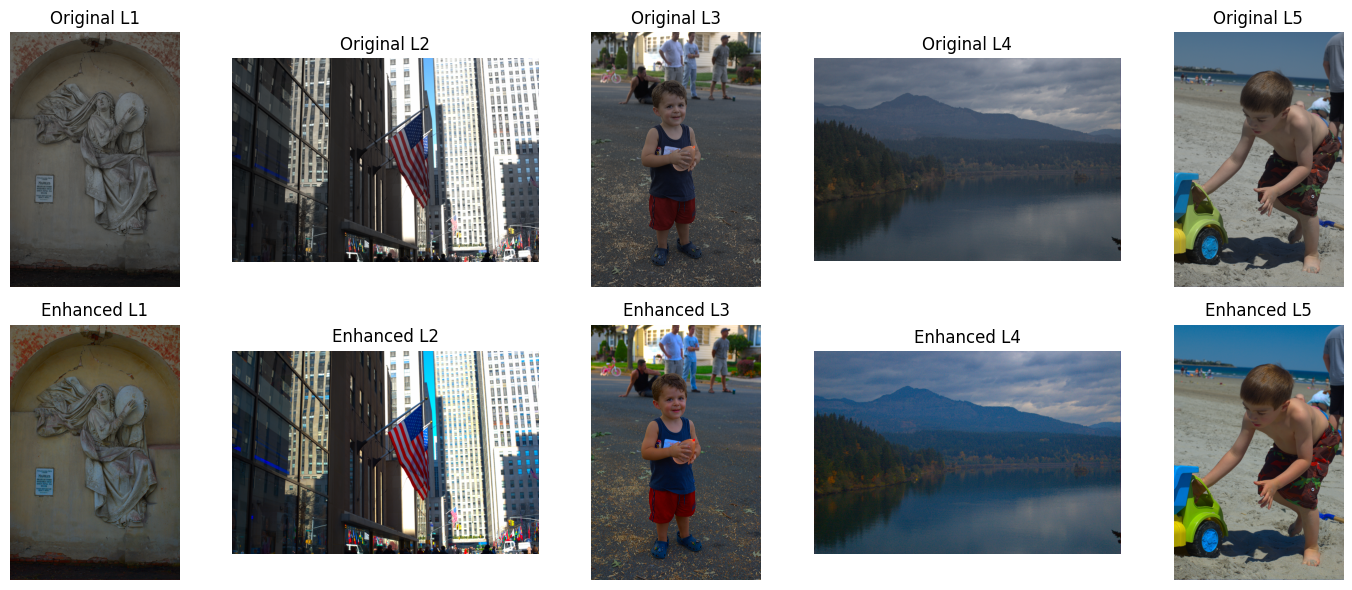

In [ ]:
# show original + enhanced images for each saturation level

import matplotlib.pyplot as plt
import numpy as np
from skimage.color import rgb2lab, lab2rgb
import rawpy

results = {}  # store processed outputs

plt.figure(figsize=(15,6))

for i, level in enumerate(range(1,6)):

    if len(saturation_groups[level]) > 0:

        sample_path = saturation_groups[level][0]

        with rawpy.imread(sample_path) as raw:
            rgb = raw.postprocess(
                use_camera_wb=True,
                no_auto_bright=True,
                output_bps=16
            )

        # --------- enhancement ----------
        rgb_norm = rgb / 65535.0
        lab = rgb2lab(rgb_norm)

        a = lab[:,:,1]
        b = lab[:,:,2]

        # scaling
        scale_map = {

            1: 2.5,
            2: 2.3,
            3: 2.1,
            4: 1.9,
            5: 1.7,
            6: 1.5,
            7: 1.3,
            8: 1.2,
            9: 1.1,
            10: 1.0
        }

        scale = scale_map[level]

        lab[:,:,1] = np.clip(a * scale, -128, 127)
        lab[:,:,2] = np.clip(b * scale, -128, 127)

        enhanced = lab2rgb(lab)

        # --------- store ----------
        results[level] = {
            "path": sample_path,
            "enhanced": enhanced
        }

        # --------- plotting ----------
        # original
        plt.subplot(2,5,i+1)
        plt.imshow(rgb_norm)
        plt.title(f"Original L{level}")
        plt.axis("off")

        # enhanced
        plt.subplot(2,5,i+6)
        plt.imshow(enhanced)
        plt.title(f"Enhanced L{level}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# create folders and save enhanced images for each saturation level

from google.colab import drive
drive.mount('/content/drive')

import os
import imageio
import numpy as np

# main folder
output_dir = "/content/drive/MyDrive/enhanced_images"
os.makedirs(output_dir, exist_ok=True)

# level folders
for level in results.keys():
    level_folder = os.path.join(output_dir, f"level_{level}")
    os.makedirs(level_folder, exist_ok=True)

# saving
for level, data in results.items():

    sample_path = data["path"]
    enhanced = data["enhanced"]

    level_folder = os.path.join(output_dir, f"level_{level}")

    # file naming
    filename = os.path.basename(sample_path).replace(".dng", ".png")
    save_path = os.path.join(level_folder, filename)

    # save image
    imageio.imwrite(save_path, (enhanced * 255).astype("uint8"))

    print(f"Saved L{level}:", save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved L1: /content/drive/MyDrive/enhanced_images/level_1/a0039-jmac_DSC3406.png
Saved L2: /content/drive/MyDrive/enhanced_images/level_2/a0052-dgw_131.png
Saved L3: /content/drive/MyDrive/enhanced_images/level_3/a0038-MB_070908_135.png
Saved L4: /content/drive/MyDrive/enhanced_images/level_4/a0050-_DSC0006.png
Saved L5: /content/drive/MyDrive/enhanced_images/level_5/a0015-DSC_0081.png


In [ ]:
import joblib

# SAVE RANDOM FOREST MODEL
joblib.dump(
    rf_model,
    "saturation_model.pkl"
)

print("Model Saved Successfully")



Model Saved Successfully


In [ ]:
from google.colab import files

files.download(
    "saturation_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>